In [2]:
import math 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
np.random.seed(42)

In [32]:
class value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self._backward = lambda : None
        self.grad = 0.0 # Gradient
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"value(data = {self.data:1f})"

    def __add__(self, other):
        other = other if isinstance(other, value) else value(other)
        out = value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad 
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, value) else value(other)
        out = value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad 
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        out = value((math.exp(2*self.data) - 1) / (math.exp(2*self.data) + 1), (self, ), _op = 'tanh')
        def _backward():
            self.grad += (1 - (out.data ** 2)) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
    
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


        

In [4]:
from graphviz import Digraph
import os
os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

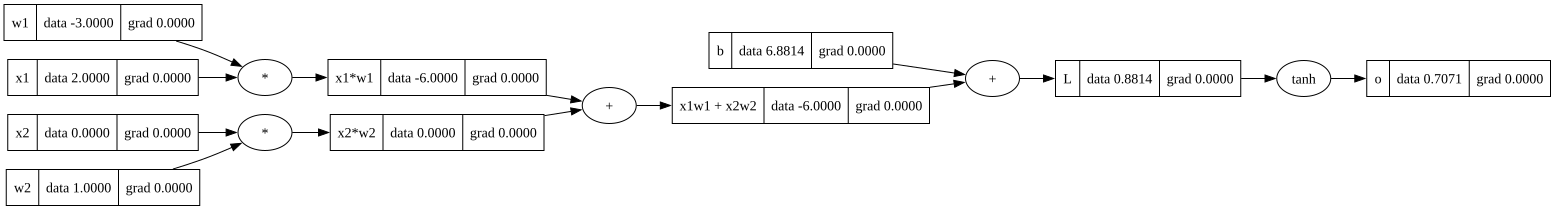

In [5]:
x1 = value(2.0); x1.label = 'x1'
x2 = value(0.0); x2.label = 'x2'

w1 = value(-3.0); w1.label = 'w1'
w2 = value(1.0); w2.label = 'w2'

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'

b = value(6.8813735870195432); b.label = 'b' # Andrej Karpathy's exact micrograd values!
wb = x1w1x2w2 + b; wb.label = 'L'

o = wb.tanh(); o.label = 'o'
draw_dot(o)

In [7]:
o.grad = 1
wb.grad = 1 - o.data ** 2
b.grad = wb.grad 
x1w1x2w2.grad = wb.grad 
x1w1.grad = b.grad 
x2w2.grad = b.grad 


global derivative = local derivative * global derivative of the connecting node
dw1 / do = (dw1 / dx1w1) * (do / dx1w1)

In [8]:
w1.grad = x1.data * x1w1.grad
x1.grad = w1.data * x1w1.grad 

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

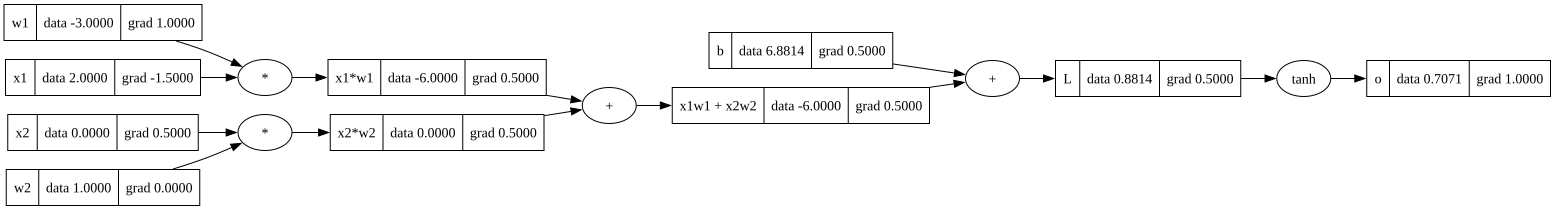

In [9]:
draw_dot(o)

# Testing automatic gradient

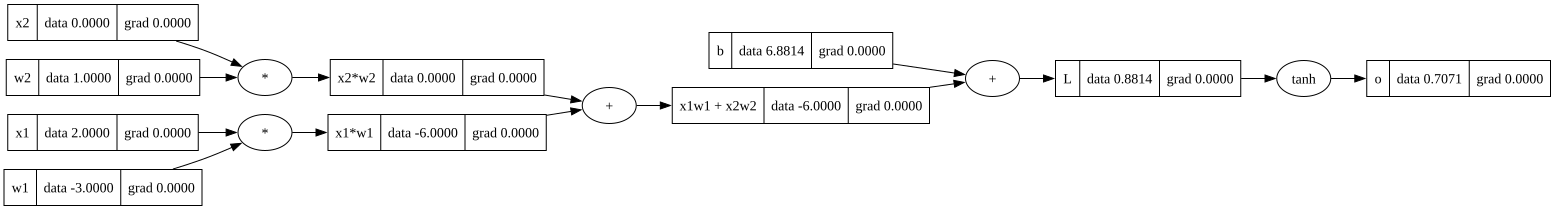

In [11]:
x1 = value(2.0); x1.label = 'x1'
x2 = value(0.0); x2.label = 'x2'

w1 = value(-3.0); w1.label = 'w1'
w2 = value(1.0); w2.label = 'w2'

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'

b = value(6.8813735870195432); b.label = 'b' # Andrej Karpathy's exact micrograd values!
wb = x1w1x2w2 + b; wb.label = 'L'

o = wb.tanh(); o.label = 'o'
draw_dot(o)

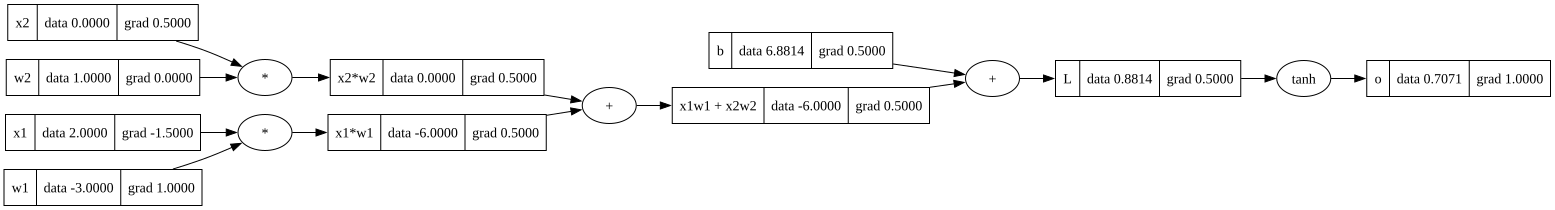

In [19]:
o.grad = 1
o._backward()
wb._backward()
b._backward()
x1w1x2w2._backward()
x2w2._backward()
x1w1._backward()
draw_dot(o)

# Texting encapsulated gradient

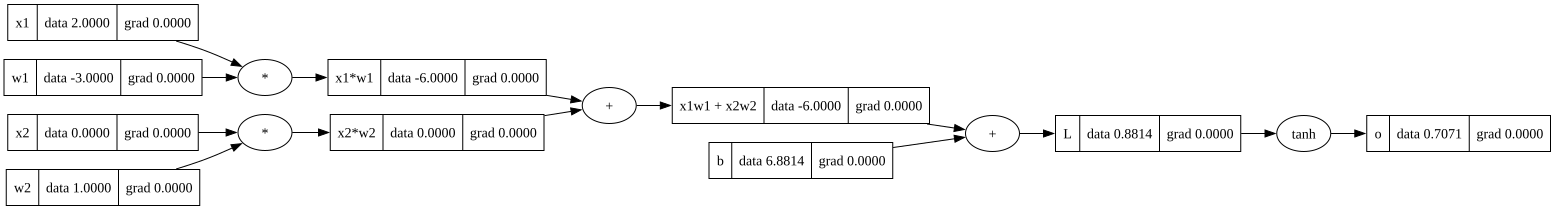

In [26]:
x1 = value(2.0); x1.label = 'x1'
x2 = value(0.0); x2.label = 'x2'

w1 = value(-3.0); w1.label = 'w1'
w2 = value(1.0); w2.label = 'w2'

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'

b = value(6.8813735870195432); b.label = 'b' # Andrej Karpathy's exact micrograd values!
wb = x1w1x2w2 + b; wb.label = 'L'

o = wb.tanh(); o.label = 'o'
draw_dot(o)

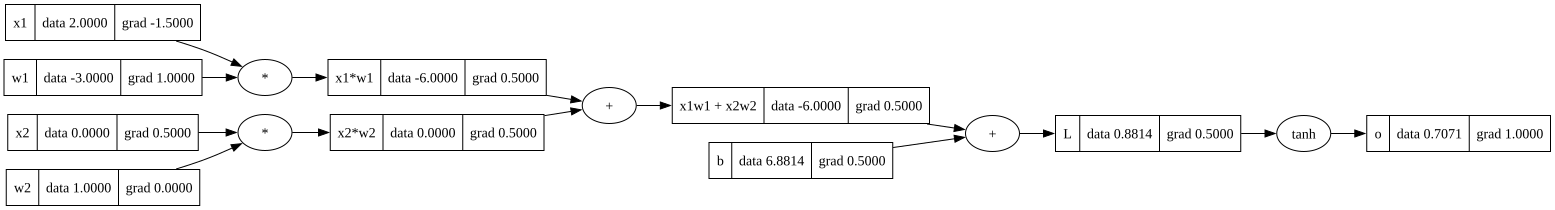

In [27]:
o.backward()
draw_dot(o)

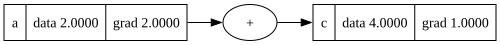

In [40]:
a = value(2, label = 'a')
c = a + a; c.label = 'c'
c.backward()
draw_dot(c)

In [41]:
a * 7

value(data = 14.000000)